# 6차시 언어 모델
#### 조대흠

---
# 생성 모델

## 1. 생성 모델의 개념


### 1-1 분류 모델 vs 생성 모델

- 분류 모델: 훈련 데이터의 각 샘플에는 정답 레이블이 존재 -> x에 대한 레이블 Y를 결정

    - 학습 목표: X에 대한 정답이 Y일 확률 계산

    - 한계: 본 적 없는 데이터에 대해서 기존의 라벨로 결론을 내려야 함

- 생성 모델: 데이터 자체의 분포를 학습해, 유사한 데이터를 만들어내는 모델

    - 학습 목표: X 자체의 확률 분포 파악

    - 특징: 이상한 입력에 대해서 존재할 확률 판단 후 거부 가능



### 1-2 생성 모델의 분류

직접 확률 밀도를 계산할 수 있는지의 여부에 따라 구분됨

- 명시적 확률 밀도 모델: 모델이 데이터의 확률 분포의 값을 직접적으로 수치화하여 출력할 수 있는 모델

    - 정확히 계산 가능한 모델: 수학적으로 확률 값을 정확하게 계산할 수 있음 ex) 자기회귀 모델

    - 근사적 밀도 모델: 확률 값을 정확히 구하기는 너무 복잡해서 근삿값이나 하한선 계산 ex)VAE

- 암시적 확률밀도 모델: 데이터의 확률 분포를 수치로 알려주지는 않지만, 분포를 따르는 데이터르르 생성 할 수 있는 몯레

    - 직접 샘플링: 신경망을 한 번 통과시키는 것만으로도 데이터 만듬 ex) GAN

    - 간접/반복적 샘플링: 여러 단계를 거쳐 점진적으로 데이터를 완성 ex)GSN, 확산 모델

---
## 2. AE, VAE

### 2-1. AE

- AE란?
    
    - 입력과 동일한 출력을 만드는 것을 목적으로 하는 신경망
    - 데이터 복원, 특성 학습에 많이 사용됨

- AE의 구조와 작동

    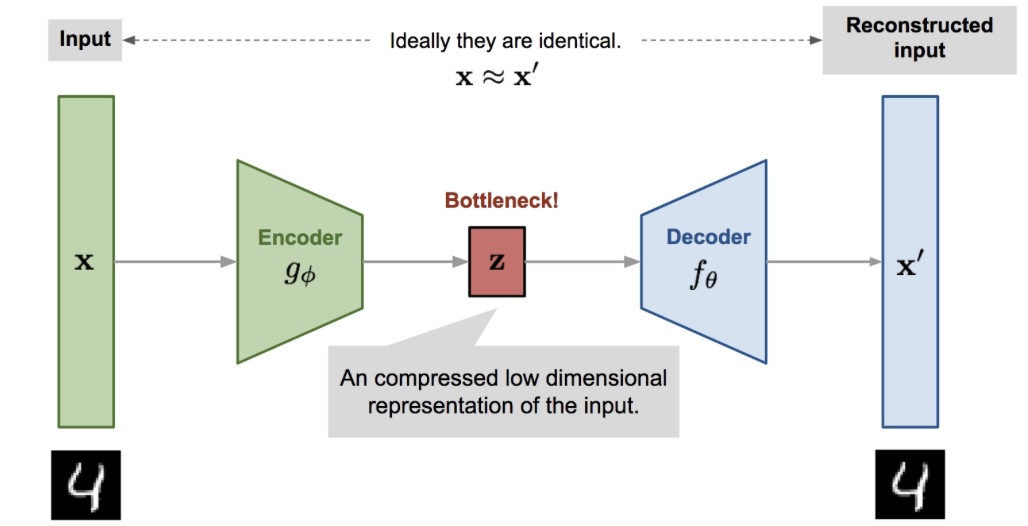


    - a. 압축 단계: 방대한 정보를 잠재벡터로 통과시키기 위해 핵심만 남기고 깎아냄
    - b. 병목 통과: 가장 중요한 정보만 남은 상태 -> 잠재 벡터(저차원으로 압축하여 함축된 정보 저장)로 부름
    - c. 복원 단계: 핵심 정보만을 단서로 삼아, 다시 원래의 커다란 이미지로 복원

- 인코더로 들어가는 입력 데이터와 디코더가 출력한 데이터가 같아지도록 훈련하는 과정 중 잠재벡터만 남기는 모델

### 2-2. VAE

- Variational Auto Encoder란?

    - VAE는 데이터의 잠재적인 구조를 학습, 원본과 닮앗지만 새로운 데이터 생성

    - AE의 결정적 한계: 데이터를 잠재 공간의 특정 점으로만 보내, 학습할 때 쓰지 않은 점은 디코더가 엉뚱한 결과 출력

    - VAE의 해결책: 잠재 벡터를 점이 아닌 가우시안 분포로 학습

    - 이미지 생성, 텍스트 생성, 신호 처리, 이미지 보간 등 새로운 데이터 생성하는데 사용

- AE vs VAE

    - 입력 데이터를 잠재 공간에 어떤 형태로 배치하느냐가 차이점

    - AE의 잠재공간: 입력 데이터를 잠재 공간의 하나의 고정된 점으로 매핑

        - 한계:데이터가 찍히지 않은 빈 공간은 학습해 본적 없는 구역

    - VAE 잠재 공간: 평균과 분산으로 표현되는 어떤 가우시안 분포

        - 구조적 특징: 연속성 / 조밀함

        - 장점: 임의의 지점을 샘플링하더라도 자연스럽고 새로운 결과물 생성 가능


- VAE의 구조와 작동: 찾고, 뽑고, 다시 그리기

    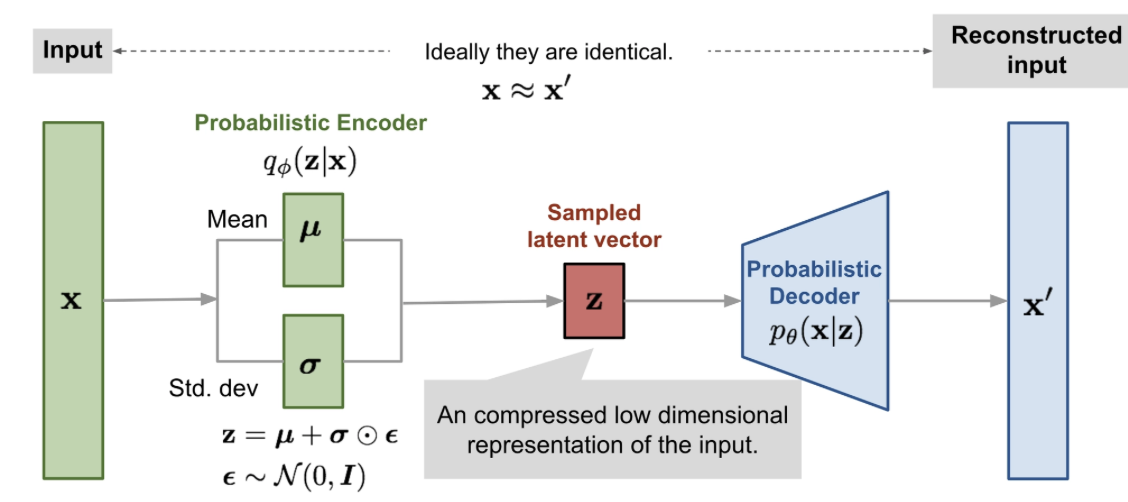

    - 데이터를 확률 분포로 변환하여 학습

    - a. 분포 예측 단계: 입력 데이터를 데이터가 존재할 확률이 높은 구역으로 매핑

    - b. 샘플링 및 재파리미터화: 예측한 분포에서 실제 디코더에 전달할 잠재 벡터를 하나 뽑는 단계

    - c. 생성 단계: 샘플링된 잠재 벡터를 단서로 사용하여 새로운 데이터 생성


### 2-3. Perplexity

- PPL: 언어 모델이 문장을 얼마나 혼란스러워하는지를 수치로 나타낸 것

- 문장 W가 희소하게 등장하면 모델이 훈련 데이터에서 더 적게 봄 -> W가 희소하게 등장하여 PPL 커짐

- 단어 개수 N이 커지면 함께 보는 단어들이 더 많아져, 희소한 부분이 있더라도 그 안에 예측이 쉬운 단어들도 같이 있어 PPL을 낮춤

- 신경망 기반 언어모델은 일반화 능력이 뛰어남 -> 이에 신경망 언어 모델로 관심이 쏠림


---

## 3. GAN

### 3-1. GAN의 개념

- GAN(Generative Adversarial Network 란?)

    - 생성자 신경망과 판별자 신경망이 적대적으로 경쟁하며, 훈련을 통하여 자신의 작업을 정교화 시켜나가는 신경망 모델

- GAN의 목적

    - 생성자: 진짜 분포에 가까운 가짜 분포를 생성하는 것

    - 판별자: 가짜 분포에 속하는지 진짜 분포에 속하는지 결정하는 것

    - 즉, 실제 데이터의 분포에 가까운 데이터를 생성하는 것이 목적 / 판별자가 구분하지 못하는 경계가 최적의 솔루션


### 3-2. GAN의 구조

- GAN은 두 개의 신경망이 MinMax Game을 수행하는 구조

    - 생성자: 
        - 입력: 우리가 제어 가능한 무작위 노이즈 입력
        - 출력: 실제 데이터와 유사한 가짜 데이터 생성
        - 목표: 판별자를 속여서 가짜를 진짜로 믿게 만드는 것

     - 판별자:
        - 입력: 실제 데이터와 가짜 데이터 모두 입력
        - 출력: 입력데이터가 진짜일 확률 출력
        - 목표: 진짜는 1, 가짜는 0으로 분류


### 3-3. GAN의 장단점

- GAN의 장점

    - 진짜 같은 가짜 생성 가능

    - 압도적인 선명도 -> VAE는 MSE를 이용하지만, GAN은 판별자를 속여야 하기 때문에 더 선명

    - 빠른 생성 속도

    - 잠재 공간의 부드러움

- GAN의 한계점

    - 학습의 불안정성

        - 진동 현상: 학습 초기에는 오차가 줄어들지만, 에폭이 늘어날수록 손실값의 진동 발생

            - 한쪽이 좋아지면 다른 쪽의 즉각 대응 때문

        - 무한루프: G, D를 번갈아 가며 업데이트 하기 때문에 무한 루프에 빠지기 쉬움

     - 훈련 초기 문제

        - 초기의 G는 엉터리 이미지를 만들고, D는 이걸 너무 쉽게 잠아냄 -> 이에 기울기 소실

     - 모드 부오기: 생성자가 판별자를 속이기 쉬운 특정 패턴 하나만 만듬

     - 지표의 부재: 얼마나 잘 학습되고 있는지를 보여주는 손실 곡선이 없음

      - 역매핑 불가능: 잠재 변수 Z에서 데이터 X를 만드는 법을 배우지만, 이미지를 넣었을 때 특징을 추출하는 구조는 없음

---

## 4. 확산 모델

### 4-1. 확산 모델의 개념

- 확산 모델이란?

    - 입력 이미지에 노이즈를 조금씩 추가하여 완전한 노이즈로 만든뒤, 이를 복원하는 과정 학습

    - 이후 입력 이미지와 유사한 확률 분포를 가진 결과 이미지 생성 모델

- 확산 모델의 목적

    - 목적: 순확산과 역확산 단계를 거쳐 생성된 결과이미지의 확률 분포를 원래 데이터의 분포와 최대한 유사하게 만드는 것

    - 모호성 모델링: 모호한 요청에 대해 작은 부분을 조금씩 상상하며 구체적인 이미지 완성


### 4-2. 확산 모델의 구조: 순확산과 역확산

#### 순확산

데이터에 점진적으로 정규분포를 가진 노이즈를 추가 -> 원래 데이터를 점차적으로 무작위 노이즈로 변형 시키는 것


원본 데이터 -> 노이즈 추가 -> 완전한 무작위 노이즈로 변환

#### 역확산

노이즈 데이터에서 원본 데이터를 재구성하는 과정 -> 순확산 과정에서 추가된 노이즈 제거

완전한 노이즈 데이터 -> 노이즈 제거 (노이즈 예측) -> 반복적인 디노이징 후 이미지 복원


### 4-3. 확산 모델의 장단점

#### 장점

압도적인 샘플 품질, 학습의 안정성, 다양성 확보

#### 단점

느린 생성 속도, 높은 계산 비용, 구조적 제약


---